In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 73


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

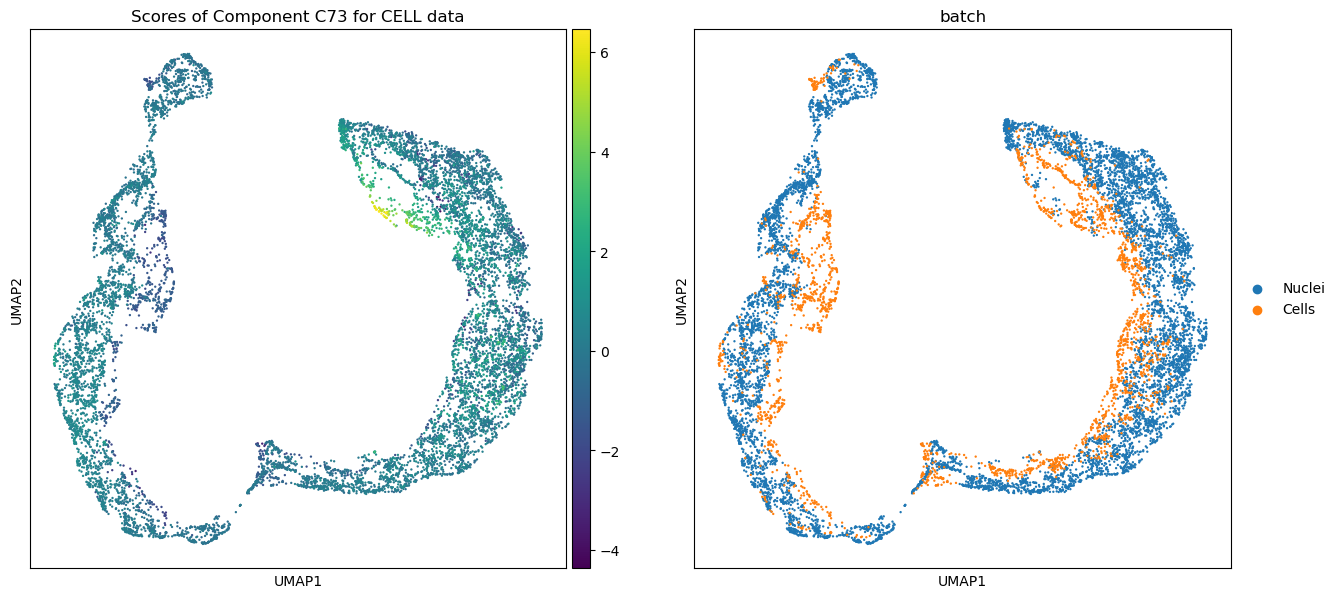

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

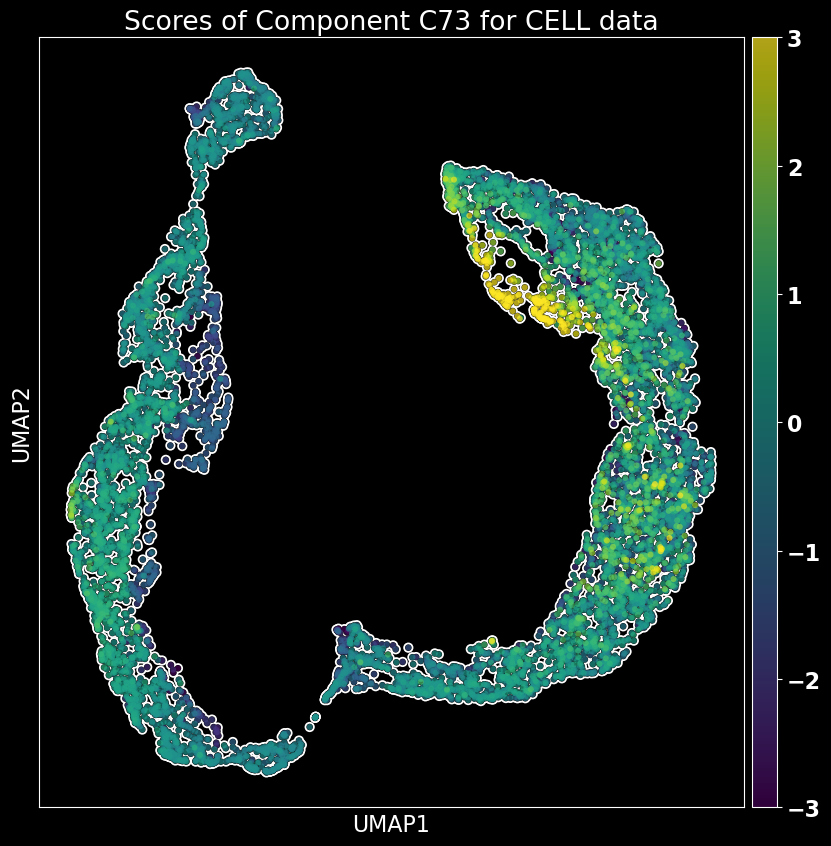

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

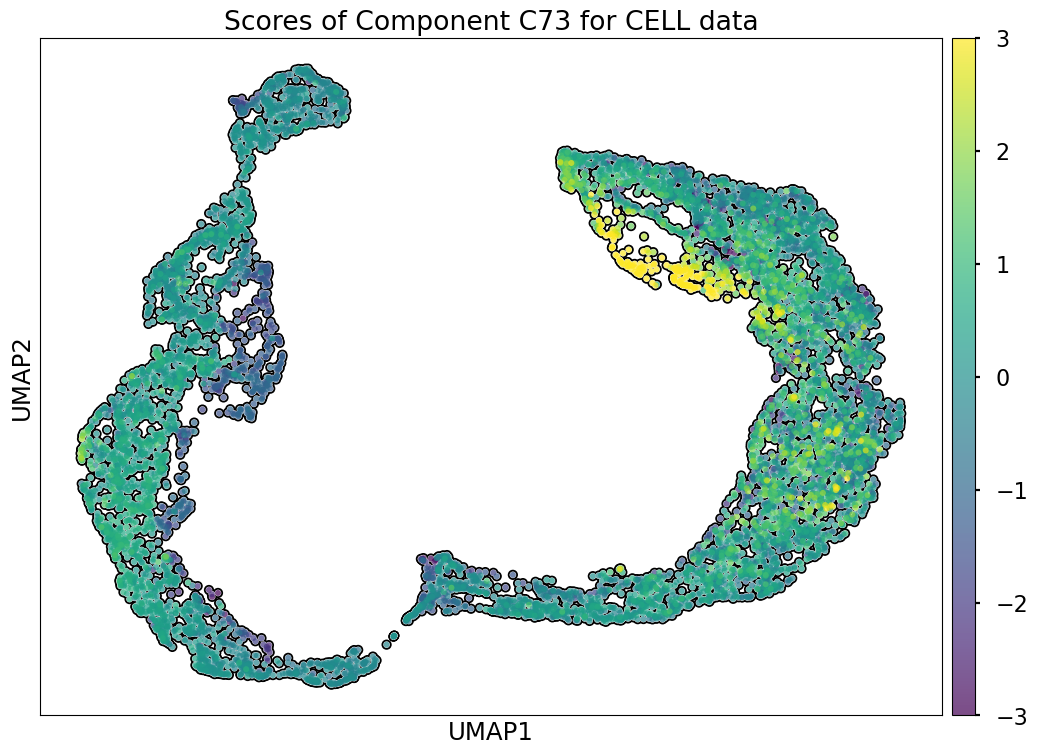

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

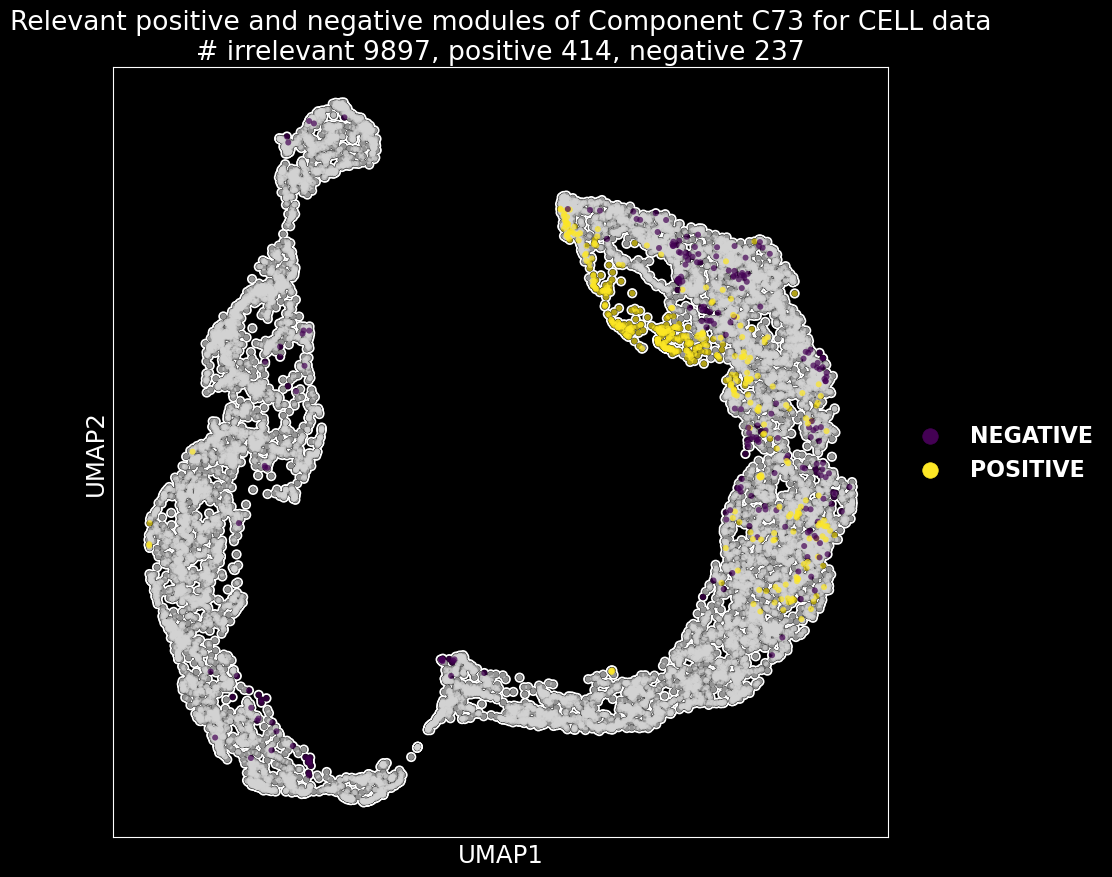

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

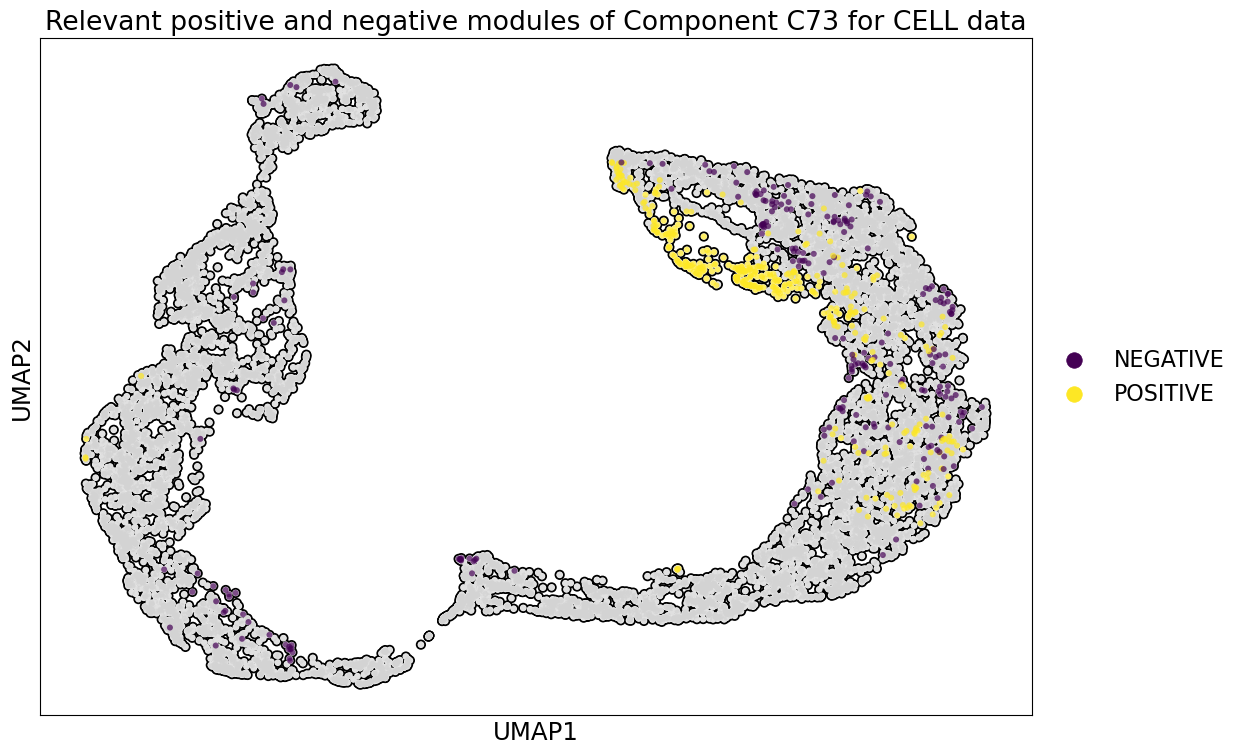

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 2.2082349367088607 var: 0.7616637951211898
Positive scores cells  - mean: 3.3035724218749998 var: 1.195429500033517


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.9595050434782608 var: 0.38077791412563267
Negative scores cells  - mean: -2.66443 var: 0.6081708719002159


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=40.58019825333751, pvalue=0.0)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-47.1394902106557, pvalue=0.0)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: Yes
Negative module batch differences: Yes


<Axes: xlabel='SDA_cellscore_C73', ylabel='Count'>

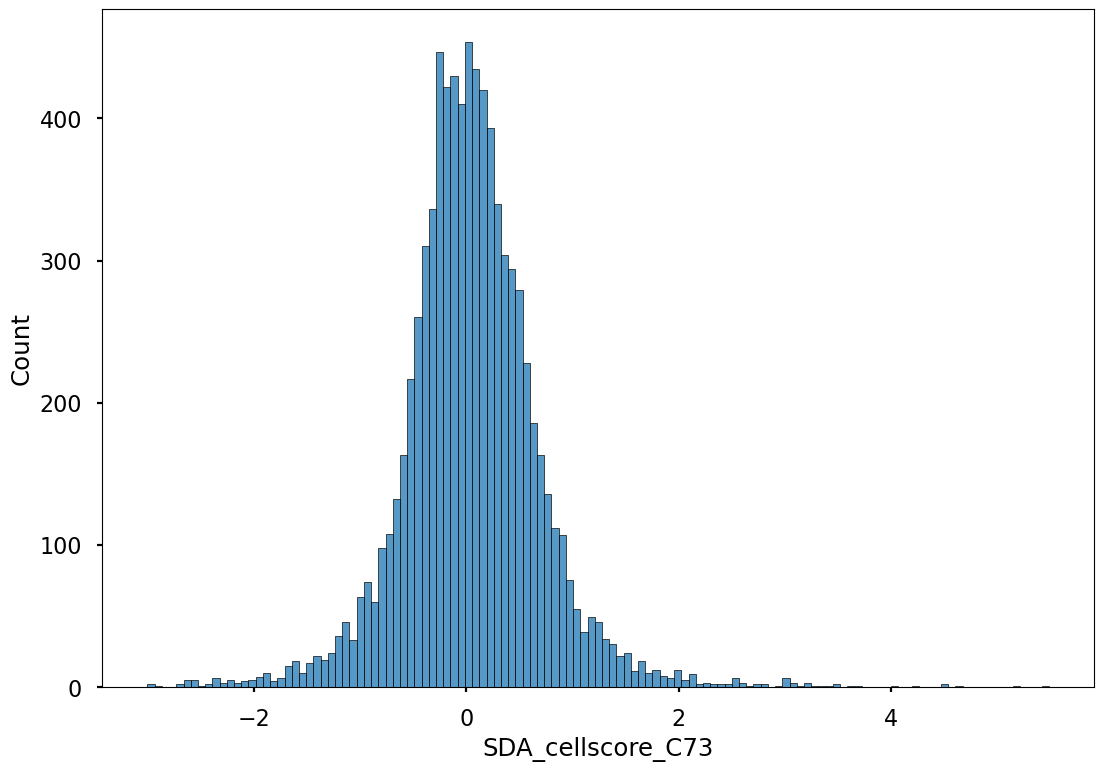

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C73', ylabel='Count'>

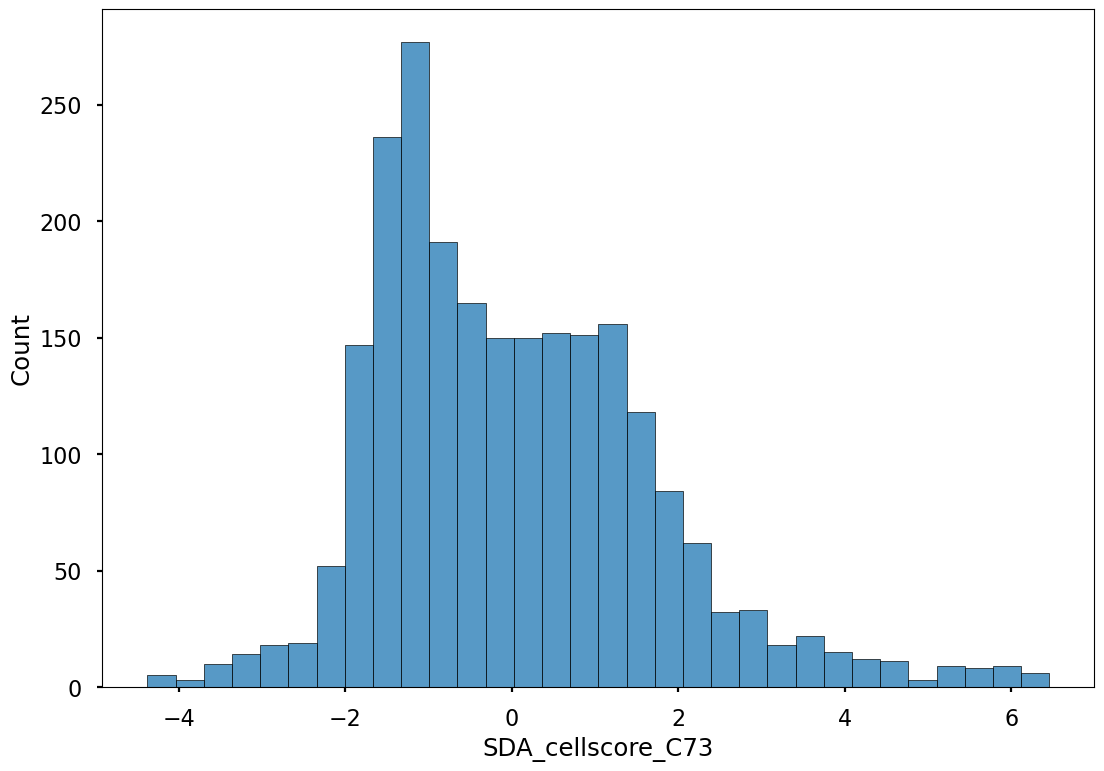

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C73: 1764


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

AURKAIP1
SSU72
RER1
MMEL1
ACTRT2
CCDC27
CHD5
CAMTA1
LZIC
CENPS
TTLL10
LOC107974981
EFHD2
CAPZB
MINOS1
KIF17
TEX46
SRSF10
STPG1
SRRM1
SYF2
STMN1
CATSPER4
ZNF683
FAM76A
ATP5IF1
MECR
KPNA6
TXLNA
AZIN2
PHC2
HMGB4
LOC104007285
TEKT2
TRAPPC3
STK40
OSCP1
DNALI1
MYCBP
AKIRIN1
NDUFS5
PABPC4
LOC104007435
CAP1
TMCO2
CITED4
SLFNL1
EBNA1BP2
CCDC24
KIF2C
GPBP1L1
IPP
LOC104007871
ATPAF1
TEX38
RPL35A
C1H1orf185
TTC39A
NRDC
LOC107966751
LOC107966756
LOC112204431
JUN
HOOK1
SLC35D1
C1H1orf141
SRSF11
ZRANB2
LRRIQ3
ERICH3
ACADM
ASB17
PIGK
MIGA1
DNAJB4
ADGRL2
GNG5
SPATA1
SSX2IP
ODF2L
BRDT
BCAR3
LOC741368
MFSD14A
EXTL2
LOC107967559
TAF13
C1H1orf194
GSTM3
UBL4B
LRIF1
TMIGD3
DDX20
LOC107968074
PPM1J
SLC16A1
LOC100614375
PHTF1
TRIM33
SYCP1
FAM46C
SPAG17
RBM8A
PLEKHO1
MRPS21
MCL1
C1H1orf56
OAZ3
S100A10
SMCP
LELP1
C1H1orf43
PBXIP1
MTX1
FDPS
ARHGEF2
TSACC
ISG20L2
CFAP45
ATP1A4
NOS1AP
SPATA46
MAEL
LOC107969148
MPC2
TIPRL
CCDC181
PRRX1
METTL13
SUCO
TEX50
KLHL20
TEX35
TOR1AIP1
CEP350
GLUL
SHCBP1L
SWT1
GLRX2
LOC107969

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C73: 632


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

LOC469457
RPL22
PARK7
ENO1
C1H1orf167
SDF4
PINK1
PITHD1
DNAJC8
RBBP4
MACF1
ATP6V0B
TESK2
PRDX1
NASP
FAAH
AGBL4
DMRTB1
NFIA
PATJ
USP1
CACHD1
JAK1
TNNI3K
SLC44A5
LRRC8C
VAV3
RSBN1
CSDE1
PHGDH
ILF2
RPS27
UBE2Q1
UAP1
NUF2
LOC469572
PRRC2C
TNFSF4
SLC9C2
FAM163A
SMG7
EDEM3
TPR
BRINP3
CDC73
KCNT2
UBE2T
ATP2B4
SNRPE
NEK2
CENPF
SUSD4
DNAH14
ENAH
SRP9
LOC107970667
AKT3
AHCTF1
ALKAL2
DDX1
TTC32
TDRD15
HADHA
SLC4A1AP
LOC107973426
PRKCE
CALM2
ACYP2
SPTBN1
RTN4
XPO1
CCT4
EHBP1
LOC107973512
EXOC6B
TPRKB
LOC107973527
TGOLN2
BUB1
COA5
MAP4K4
RANBP2
IWS1
LOC104005193
GPD2
HNRNPA3
TTN
CCDC141
UBE2E3
SLC39A10
SF3B1
HSPE1
FAM117B
LANCL1
SPAG16
RPL37A
DNAJB2
LOC104005386
LOC459972
DAW1
NCL
PDE6D
DIS3L2
GIGYF2
STK25
SRGAP3
LOC107970599
GOLGA4
EXOSC7
PRSS45
MAP4
RHOA
ZMYND10
DNAH1
CACNA2D3
ARHGEF3
SLMAP
C3H3orf67
FHIT
LOC104005593
MAGI1
FRMD4B
LOC100612575
MORC1
IGSF11
ALG1L
LOC107970755
IFT122
TMCC1
TMEM108
CLSTN2
PXYLP1
GYG1
LOC107970827
LOC107970832
SEC62
NAALADL2
ACTL6A
CCDC39
EIF4A2
LPP
TP63
LRPAP1
ZFYVE

#### Cells scores by cluster

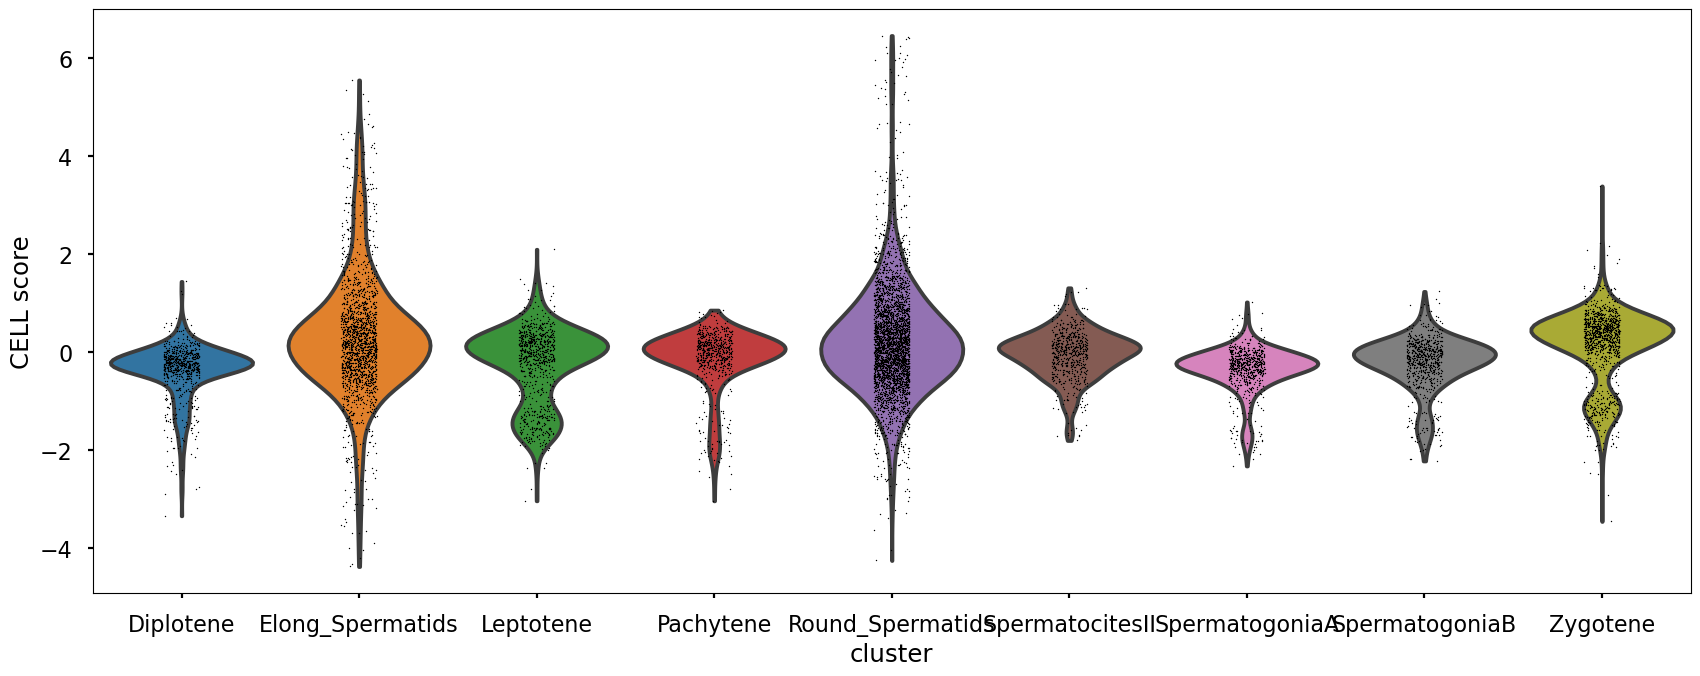

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

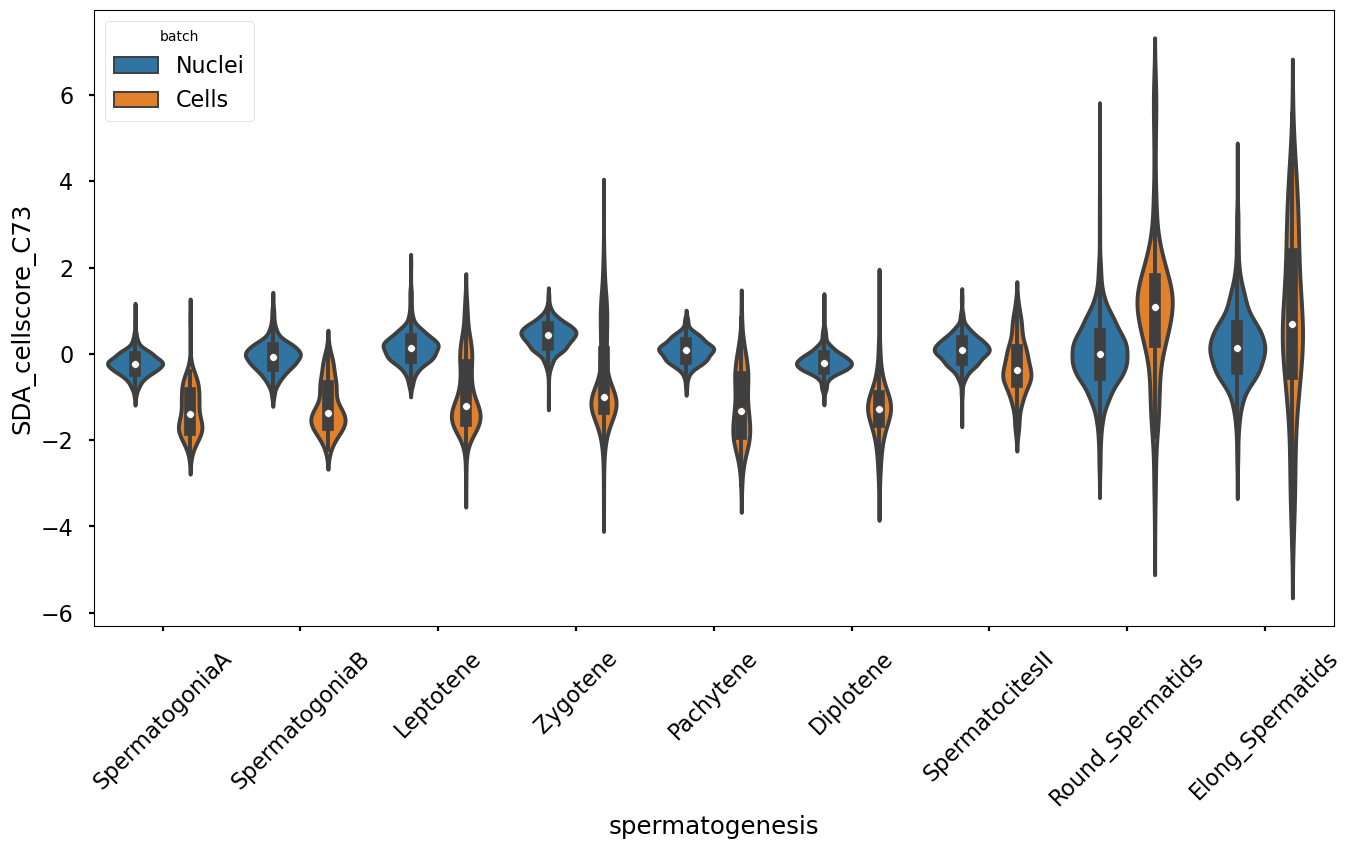

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C73')

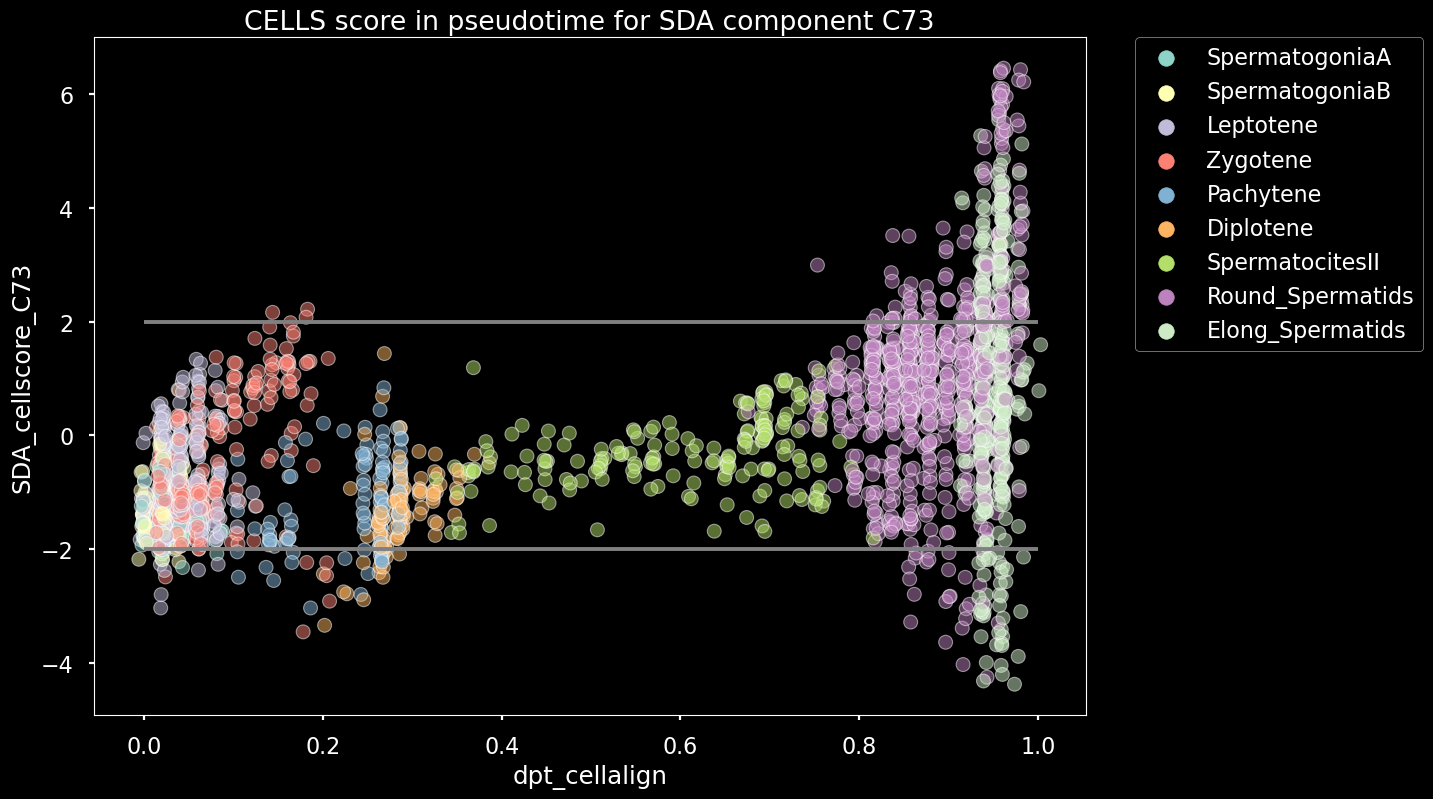

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C73')

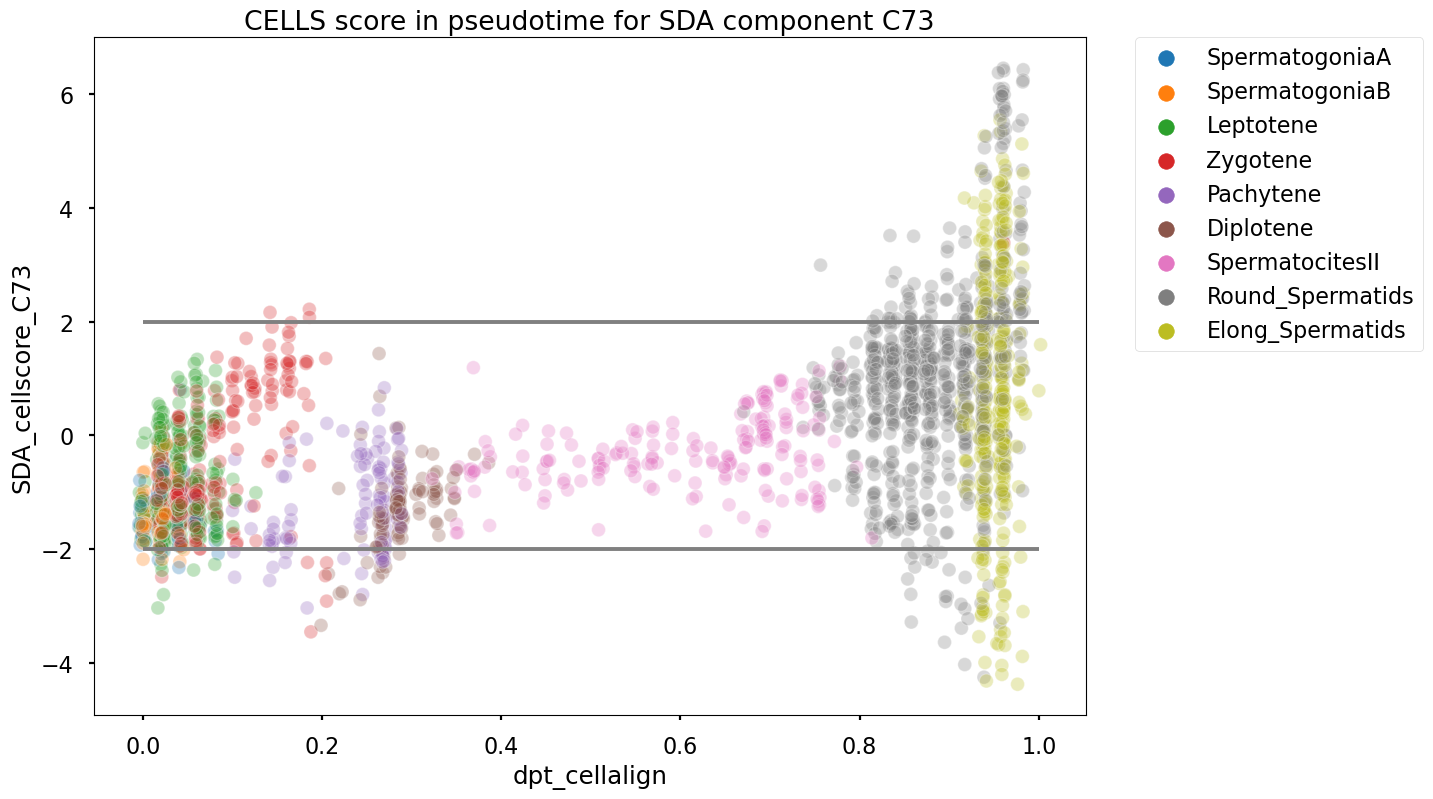

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C73')

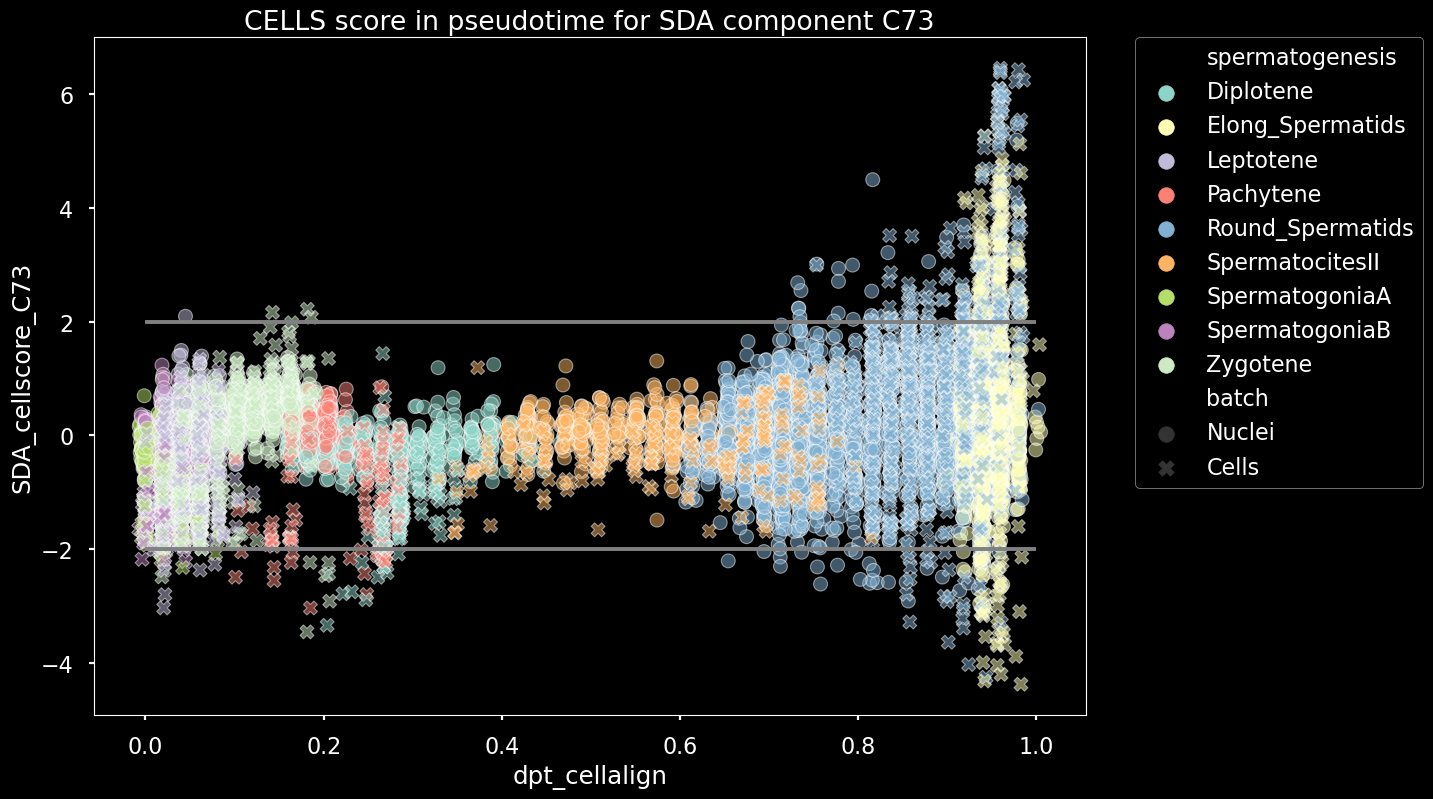

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C73')

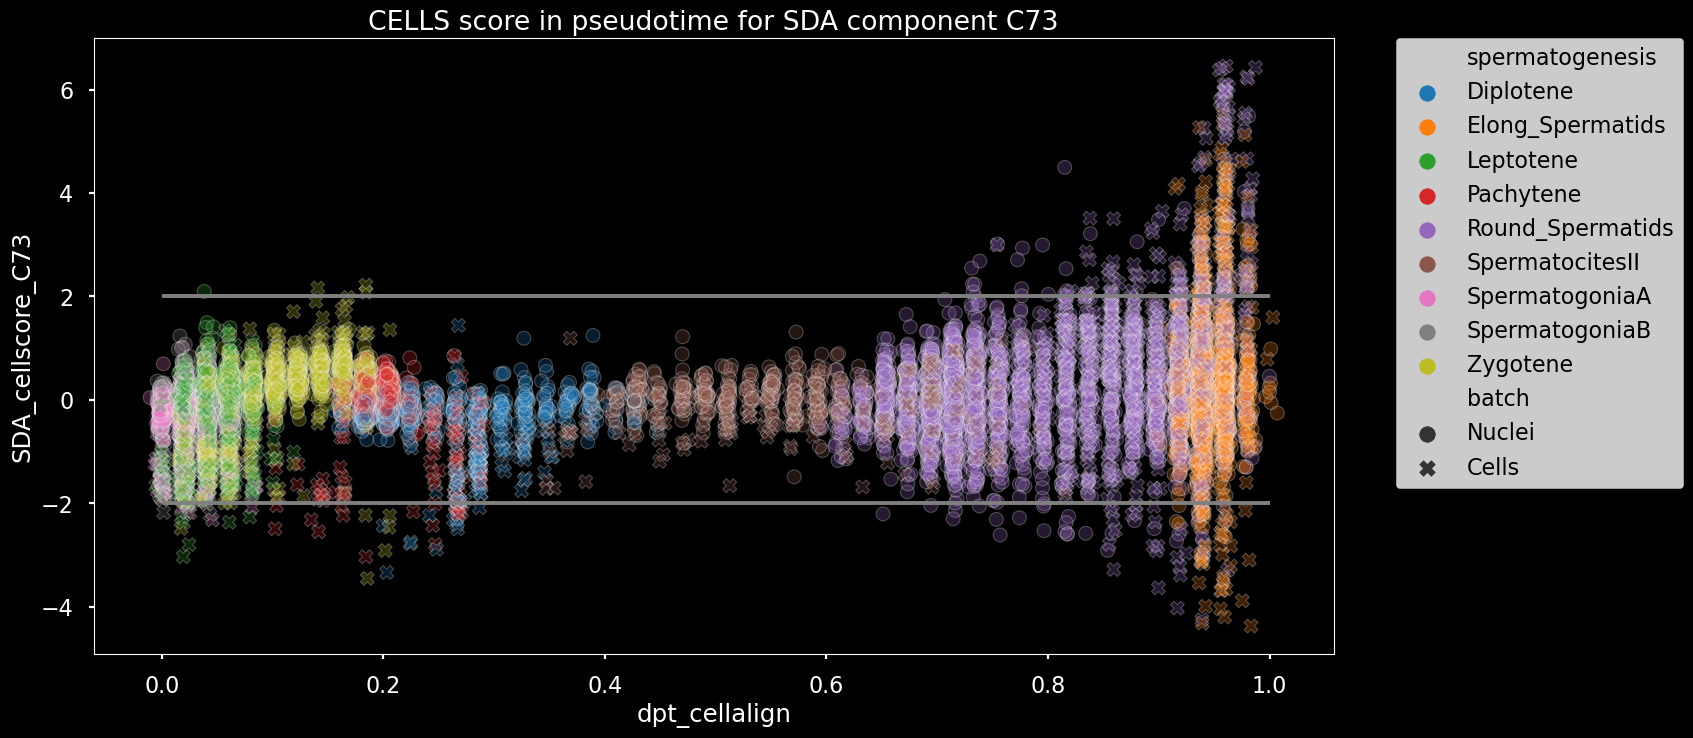

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
281,GO_Cellular_Component_2023,Acrosomal Vesicle (GO:0001669),30/64,1.514678e-15,4.695501e-13,0,0,9.262162,316.058054,SPAG17;CATSPER3;CATSPER4;ACTL7A;SPESP1;SPATA1;...
282,GO_Cellular_Component_2023,9+2 Motile Cilium (GO:0097729),28/70,1.728742e-12,2.679550e-10,0,0,6.986943,189.231765,SPEF2;DNAH8;CUL3;RSPH9;TTC29;LYZL4;DNALI1;AK8;...
283,GO_Cellular_Component_2023,Sperm Flagellum (GO:0036126),23/60,4.564710e-10,4.716867e-08,0,0,6.497928,139.754151,SPEF2;DNAH8;CUL3;ATP1B3;TTC29;LYZL4;CABCOCO1;D...
284,GO_Cellular_Component_2023,Acrosomal Membrane (GO:0002080),9/14,4.208461e-07,3.261557e-05,0,0,18.698462,274.512089,CCDC136;EQTN;SPACA1;TMEM190;SPACA3;TEKT3;RAB6A...
285,GO_Cellular_Component_2023,Motile Cilium (GO:0031514),20/73,3.253494e-06,2.017166e-04,0,0,3.934352,49.713607,ROPN1B;OFD1;RSPH9;CFAP300;CABS1;AKAP4;DNALI1;A...
286,GO_Cellular_Component_2023,Mitochondrial Respiratory Chain Complex I (GO:...,14/41,5.869435e-06,2.599321e-04,0,0,5.395259,64.989956,NDUFA8;NDUFA13;NDUFA6;NDUFB6;NDUFA5;NDUFA12;ND...
287,GO_Cellular_Component_2023,Respiratory Chain Complex I (GO:0045271),14/41,5.869435e-06,2.599321e-04,0,0,5.395259,64.989956,NDUFA8;NDUFA13;NDUFA6;NDUFB6;NDUFA5;NDUFA12;ND...
288,GO_Cellular_Component_2023,Cilium (GO:0005929),44/257,1.482358e-05,5.744138e-04,0,0,2.164570,24.068488,ROPN1B;FANK1;ARL2;RSPH9;TULP2;AKAP4;CFAP300;KI...
591,Human_Gene_Atlas,TestisIntersitial,165/568,2.025311e-45,1.579742e-43,0,0,4.566199,469.910316,TSKS;ROPN1B;CLPB;SIRPD;AQP5;SPATA20;ALKBH7;CAS...
592,Human_Gene_Atlas,TestisGermCell,71/314,8.351970e-14,3.257268e-12,0,0,3.105265,93.511006,BTG4;CRISP2;CALR3;DDX3X;CLPB;CEP164;LRRC6;AQP5...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
281,GO_Cellular_Component_2023,Acrosomal Vesicle (GO:0001669),30/64,4.695501e-13,9.262162,316.058054,SPAG17;CATSPER3;CATSPER4;ACTL7A;SPESP1;SPATA1;...,73P,Yes,414
282,GO_Cellular_Component_2023,9+2 Motile Cilium (GO:0097729),28/70,2.679550e-10,6.986943,189.231765,SPEF2;DNAH8;CUL3;RSPH9;TTC29;LYZL4;DNALI1;AK8;...,73P,Yes,414
283,GO_Cellular_Component_2023,Sperm Flagellum (GO:0036126),23/60,4.716867e-08,6.497928,139.754151,SPEF2;DNAH8;CUL3;ATP1B3;TTC29;LYZL4;CABCOCO1;D...,73P,Yes,414
284,GO_Cellular_Component_2023,Acrosomal Membrane (GO:0002080),9/14,3.261557e-05,18.698462,274.512089,CCDC136;EQTN;SPACA1;TMEM190;SPACA3;TEKT3;RAB6A...,73P,Yes,414
285,GO_Cellular_Component_2023,Motile Cilium (GO:0031514),20/73,2.017166e-04,3.934352,49.713607,ROPN1B;OFD1;RSPH9;CFAP300;CABS1;AKAP4;DNALI1;A...,73P,Yes,414
286,GO_Cellular_Component_2023,Mitochondrial Respiratory Chain Complex I (GO:...,14/41,2.599321e-04,5.395259,64.989956,NDUFA8;NDUFA13;NDUFA6;NDUFB6;NDUFA5;NDUFA12;ND...,73P,Yes,414
287,GO_Cellular_Component_2023,Respiratory Chain Complex I (GO:0045271),14/41,2.599321e-04,5.395259,64.989956,NDUFA8;NDUFA13;NDUFA6;NDUFB6;NDUFA5;NDUFA12;ND...,73P,Yes,414
288,GO_Cellular_Component_2023,Cilium (GO:0005929),44/257,5.744138e-04,2.164570,24.068488,ROPN1B;FANK1;ARL2;RSPH9;TULP2;AKAP4;CFAP300;KI...,73P,Yes,414
591,Human_Gene_Atlas,TestisIntersitial,165/568,1.579742e-43,4.566199,469.910316,TSKS;ROPN1B;CLPB;SIRPD;AQP5;SPATA20;ALKBH7;CAS...,73P,Yes,414
592,Human_Gene_Atlas,TestisGermCell,71/314,3.257268e-12,3.105265,93.511006,BTG4;CRISP2;CALR3;DDX3X;CLPB;CEP164;LRRC6;AQP5...,73P,Yes,414


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,18/158,2.716192e-06,6.681832e-04,0,0,4.026338,51.602672,RPL21;RPS5;RPLP1;RPL22;RPS6;RPL13A;RPL23A;MRPL...
1,KEGG_2021_Human,Spliceosome,17/150,5.492212e-06,6.755420e-04,0,0,3.997738,48.421323,HSPA8;SF3B2;HNRNPA3;ALYREF;DDX42;U2AF1;THOC2;H...
246,GO_Cellular_Component_2023,Nucleus (GO:0005634),206/4487,1.597150e-09,4.647706e-07,0,0,1.704179,34.518228,TESK2;ENO1;PWP1;RPL6;ACTB;TRIM28;FTH1;ADNP2;EP...
247,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),12/52,5.799268e-08,5.625290e-06,0,0,9.352258,155.836200,RPL7A;RPL18A;RPL21;RPLP1;RPL22;RPL37A;RPL13A;R...
248,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),12/52,5.799268e-08,5.625290e-06,0,0,9.352258,155.836200,RPL7A;RPL18A;RPL21;RPLP1;RPL22;RPL37A;RPL13A;R...
249,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,218/5175,6.443690e-07,4.687784e-05,0,0,1.530845,21.822193,SLC4A1AP;TESK2;ENO1;PWP1;RPL6;ACTB;TRIM28;FTH1...
250,GO_Cellular_Component_2023,Polysomal Ribosome (GO:0042788),8/28,1.688933e-06,9.829587e-05,0,0,12.402564,164.847612,RPL7A;RPS28;NUFIP2;RPL18A;EIF3H;RPL18;RPL6;RPL19
251,GO_Cellular_Component_2023,Ribosome (GO:0005840),11/61,2.859630e-06,1.386921e-04,0,0,6.843736,87.359045,RPL7A;RPS28;RPS27;RPL18A;NUFIP2;RPS5;RPL13A;EI...
252,GO_Cellular_Component_2023,Cell-Substrate Junction (GO:0030055),30/395,9.554114e-06,3.971782e-04,0,0,2.594502,29.988656,RPLP1;CLTC;TNC;LPP;RPL6;ACTB;ACTG1;AKAP12;RPL7...
253,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,65/1195,1.331683e-05,4.843998e-04,0,0,1.850244,20.771733,TOP2A;RIPOR2;SRP19;CLTC;HMGB2;CLU;PWP1;ACTB;AC...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ribosome,18/158,6.681832e-04,4.026338,51.602672,RPL21;RPS5;RPLP1;RPL22;RPS6;RPL13A;RPL23A;MRPL...,73N,Yes,237
1,KEGG_2021_Human,Spliceosome,17/150,6.755420e-04,3.997738,48.421323,HSPA8;SF3B2;HNRNPA3;ALYREF;DDX42;U2AF1;THOC2;H...,73N,Yes,237
246,GO_Cellular_Component_2023,Nucleus (GO:0005634),206/4487,4.647706e-07,1.704179,34.518228,TESK2;ENO1;PWP1;RPL6;ACTB;TRIM28;FTH1;ADNP2;EP...,73N,Yes,237
247,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),12/52,5.625290e-06,9.352258,155.836200,RPL7A;RPL18A;RPL21;RPLP1;RPL22;RPL37A;RPL13A;R...,73N,Yes,237
248,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),12/52,5.625290e-06,9.352258,155.836200,RPL7A;RPL18A;RPL21;RPLP1;RPL22;RPL37A;RPL13A;R...,73N,Yes,237
249,GO_Cellular_Component_2023,Intracellular Membrane-Bounded Organelle (GO:0...,218/5175,4.687784e-05,1.530845,21.822193,SLC4A1AP;TESK2;ENO1;PWP1;RPL6;ACTB;TRIM28;FTH1...,73N,Yes,237
250,GO_Cellular_Component_2023,Polysomal Ribosome (GO:0042788),8/28,9.829587e-05,12.402564,164.847612,RPL7A;RPS28;NUFIP2;RPL18A;EIF3H;RPL18;RPL6;RPL19,73N,Yes,237
251,GO_Cellular_Component_2023,Ribosome (GO:0005840),11/61,1.386921e-04,6.843736,87.359045,RPL7A;RPS28;RPS27;RPL18A;NUFIP2;RPS5;RPL13A;EI...,73N,Yes,237
252,GO_Cellular_Component_2023,Cell-Substrate Junction (GO:0030055),30/395,3.971782e-04,2.594502,29.988656,RPLP1;CLTC;TNC;LPP;RPL6;ACTB;ACTG1;AKAP12;RPL7...,73N,Yes,237
253,GO_Cellular_Component_2023,Intracellular Non-Membrane-Bounded Organelle (...,65/1195,4.843998e-04,1.850244,20.771733,TOP2A;RIPOR2;SRP19;CLTC;HMGB2;CLU;PWP1;ACTB;AC...,73N,Yes,237


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

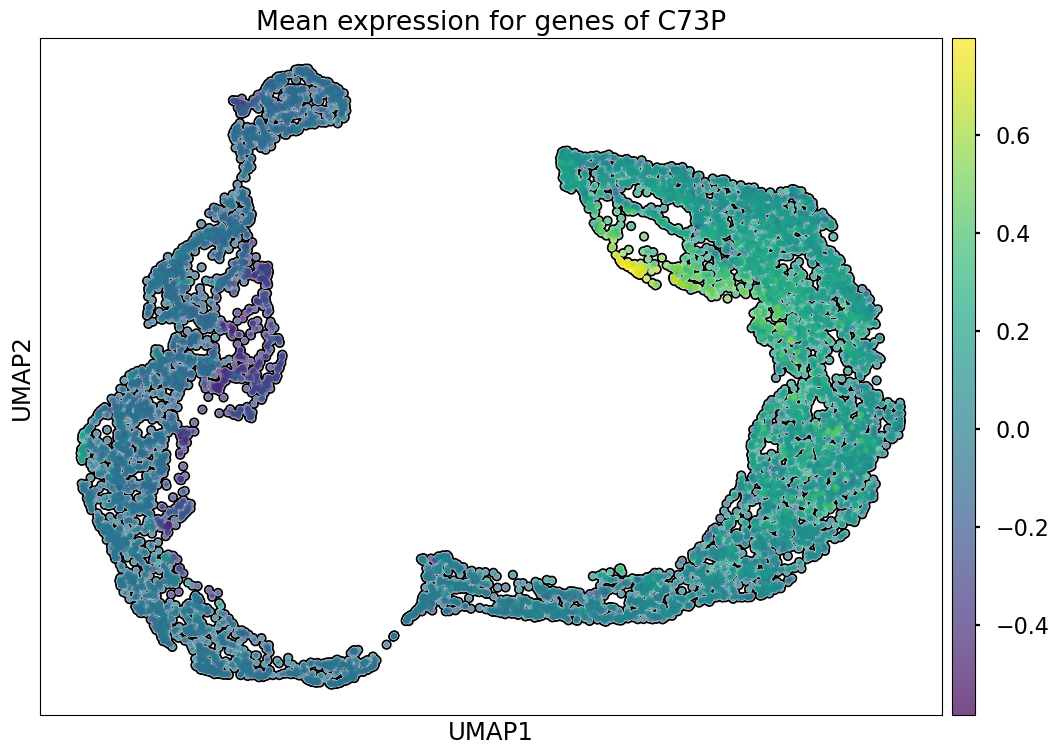

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

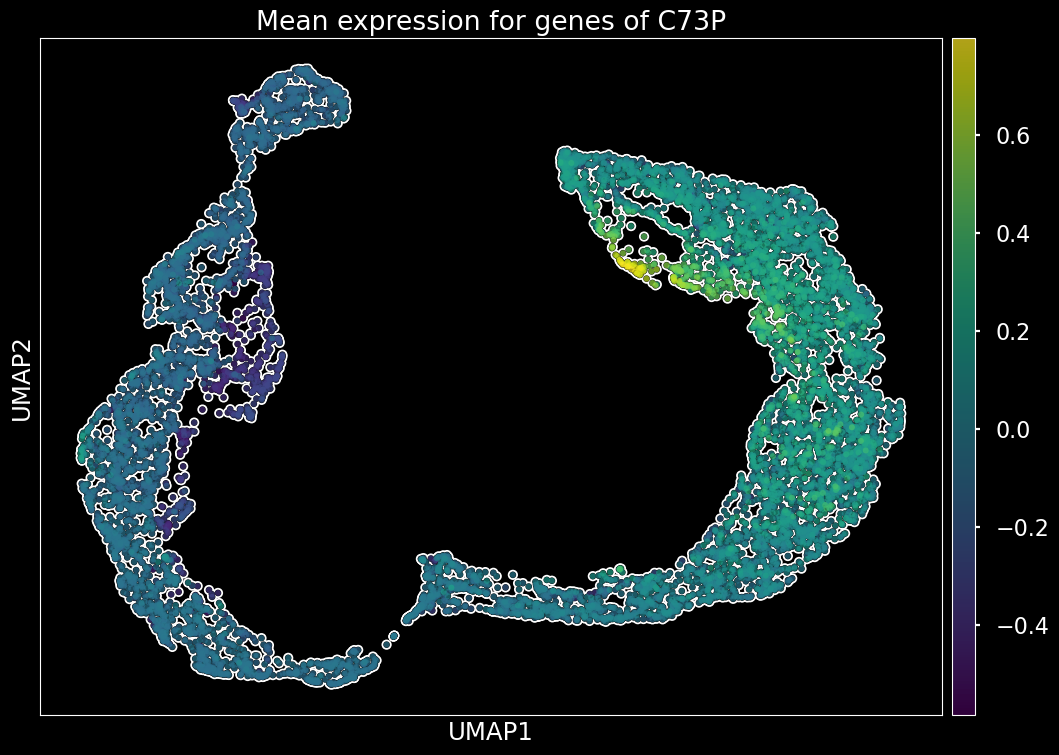

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

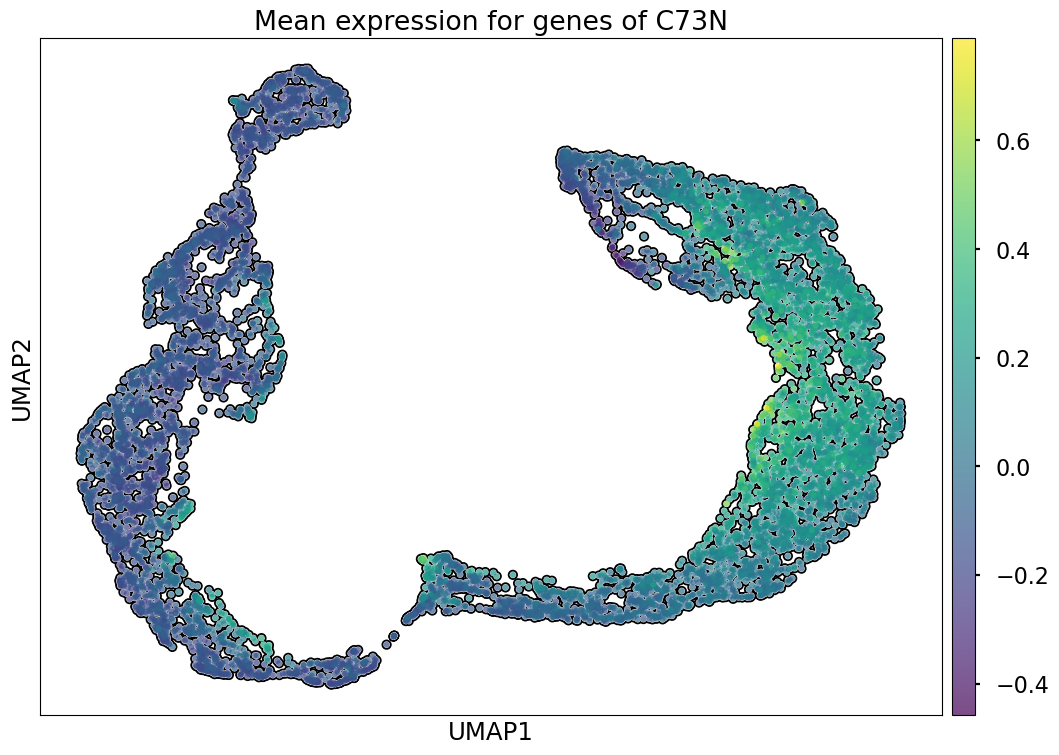

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

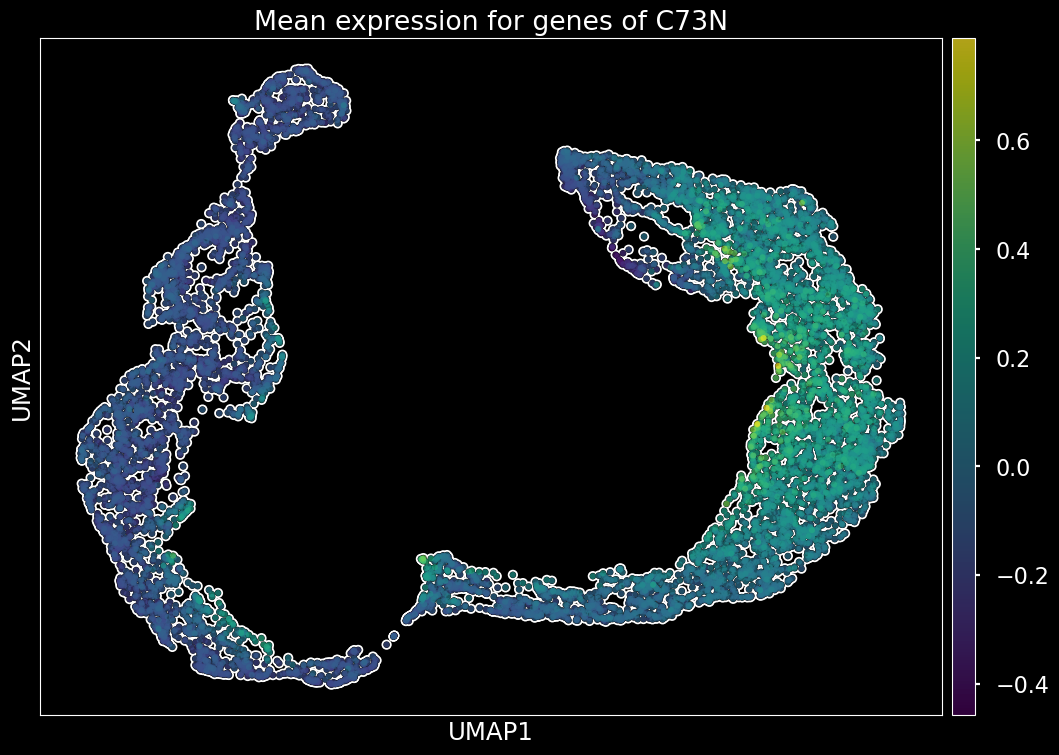

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)